## settings that increases chances of infeasible/unbounded solution (status = 4):
1. large M
2. large number of particles
3. small n_trades (larger bayesian uncertainty)

In [33]:
%load_ext autoreload
%autoreload 2
import pickle
import os
import arviz as az


import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
import pandas as pd
import scipy.stats as stats
from tqdm import tqdm


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:


def get_mip_info_multiple(base_dirs):
    # Combine data from multiple directories
    all_data = []
    if not isinstance(base_dirs, list):
        base_dirs = [base_dirs]
        
    for base_dir in base_dirs:
        df = get_mip_info(base_dir)
        df['base_dir'] = os.path.basename(base_dir)
        all_data.append(df)
    
    combined_df = pd.concat(all_data, ignore_index=True)
    return combined_df

def get_mip_info(base_dir):
    # Storage for all trade data
    file_info = []

    # Iterate through subfolders
    for subfolder in tqdm(os.listdir(base_dir)):
        subfolder_path = os.path.join(base_dir, subfolder)
        if os.path.isdir(subfolder_path):
            print(f"Processing subfolder: {subfolder}")
            
            # Iterate through files in subfolder
            for filename in os.listdir(subfolder_path):
                if filename.endswith('.pkl'):
                    file_path = os.path.join(subfolder_path, filename)
                    # print(f"  Reading file: {filename}")
                    
                    with open(file_path, 'rb') as f:
                        data = pickle.load(f)
                    
                    
                    # Extract key info from filename and subfolder
                    file_info.append({
                        'subfolder': subfolder,
                        'filename': filename,
                        'trades': data['trades'],
                        'status': data.get('status', 'unknown'),
                        'obj_val': data.get('obj_val', np.nan),
                        'runtime': data.get('runtime', np.nan)
                    })
                            

    # Plot all trade trajectories
    # Initialize list to store data
    data_rows = []

    for i, info in enumerate(file_info):
        ntrades = int(info['filename'].split('_')[2])
        seed = info['filename'].split('_')[-1].split('.')[0]
        trades = np.array(info['trades'])
            
        # Create a row with ntrades, seed, and each trade element as separate columns
        
        row = {
            'ntrades': ntrades,
            'seed': seed
        }
        
        for key, value in info.items():
            if key != 'trades':
                row[key] = value
        # Add each trade element as a separate column (trade_0, trade_1, ..., trade_10)
        for j, trade in enumerate(trades):
            row[f'trade_{j}'] = trade
        
        data_rows.append(row)

    # Create DataFrame
    df = pd.DataFrame(data_rows)
    
    return df
        


: 

In [34]:

# Base directory
base_dirs = ['/nfs/home/dannis/AC-model/TIM_opt_results_20250830_thresh5_n1000',
             '/nfs/home/dannis/AC-model/TIM_opt_results_20250909_thresh1_n1000',
             '/nfs/home/dannis/AC-model/TIM_opt_results_20250909_thresh2_n1000',
             '/nfs/home/dannis/AC-model/TIM_opt_results_20250909_thresh3_n1000',
             '/nfs/home/dannis/AC-model/TIM_opt_results_20250909_thresh7_n1000',
             '/nfs/home/dannis/AC-model/TIM_opt_results_20250909_thresh10_n1000']

# Combine data from multiple directories
all_data = []
for base_dir in base_dirs:
    threshold = int(base_dir.split('_thresh')[-1].split('_')[0])
    df = get_mip_info(base_dir)
    df['base_dir'] = os.path.basename(base_dir)
    df['threshold'] = threshold/100
    all_data.append(df)

combined_df = pd.concat(all_data, ignore_index=True)

 57%|█████▋    | 4/7 [00:00<00:00, 38.23it/s]

Processing subfolder: 20_nscenarios_1000
Processing subfolder: 1000_nscenarios_1000
Processing subfolder: 10_nscenarios_1000
Processing subfolder: 400_nscenarios_1000
Processing subfolder: 150_nscenarios_1000
Processing subfolder: 50_nscenarios_1000


 40%|████      | 2/5 [00:00<00:00, 13.87it/s]

Processing subfolder: 1000_nscenarios_1000
Processing subfolder: 400_nscenarios_1000
Processing subfolder: 150_nscenarios_1000


100%|██████████| 5/5 [00:00<00:00, 15.35it/s]


...

100%|██████████| 5/5 [00:00<00:00, 42.34it/s]


Processing subfolder: 400_nscenarios_1000
Processing subfolder: 150_nscenarios_1000
Processing subfolder: 50_nscenarios_1000


  0%|          | 0/6 [00:00<?, ?it/s]

Processing subfolder: 1000_nscenarios_1000
Processing subfolder: 400_nscenarios_1000
Processing subfolder: 50_nscenarios_10000
Processing subfolder: 150_nscenarios_1000
Processing subfolder: 50_nscenarios_1000


100%|██████████| 6/6 [00:00<00:00, 51.24it/s]


/tmp/ipykernel_2122363/1798976096.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  combined_df.groupby('ntrades').apply(lambda x: (x.status == 4).mean()).plot(


<Axes: title={'center': 'Proportion of infeasible runs'}, xlabel='Number of Trades in training data'>

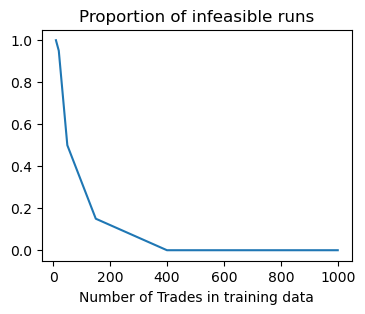

In [35]:
# count the number of rows where status == 4
combined_df.groupby('ntrades').apply(lambda x: (x.status == 4).mean()).plot(
    title='Proportion of infeasible runs', xlabel='Number of Trades in training data',
    figsize=(4,3))

In [37]:
combined_df.groupby(['ntrades', 'threshold']).apply(lambda x: (x.status == 4).mean()).unstack().dropna()

/tmp/ipykernel_2122363/2004446834.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  combined_df.groupby(['ntrades', 'threshold']).apply(lambda x: (x.status == 4).mean()).unstack().dropna()


threshold,0.01,0.02,0.03,0.05,0.07,0.10
ntrades,,,,,,
50,0.50,0.50,0.50,0.50,0.50,0.50
150,0.15,0.15,0.15,0.15,0.15,0.15
400,0.00,0.00,0.00,0.00,0.00,0.00
1000,0.00,0.00,0.00,0.00,0.00,0.00


In [50]:

# Base directory
base_dirs = ['/nfs/home/dannis/AC-model/TIM_opt_results_20250909_thresh10_n1000',
             '/nfs/home/dannis/AC-model/TIM_opt_results_20250909_thresh10_n2000',
             '/nfs/home/dannis/AC-model/TIM_opt_results_20250909_thresh10_n5000']

# Combine data from multiple directories
all_data = []
for base_dir in base_dirs:
    nscenarios = int(base_dir.split('_')[-1][1:])
    df = get_mip_info(base_dir)
    df['base_dir'] = os.path.basename(base_dir)
    df['nscenarios'] = nscenarios
    all_data.append(df)

combined_df = pd.concat(all_data, ignore_index=True)

100%|██████████| 6/6 [00:00<00:00, 519.84it/s]


Processing subfolder: 1000_nscenarios_1000
Processing subfolder: 400_nscenarios_1000
Processing subfolder: 50_nscenarios_10000
Processing subfolder: 150_nscenarios_1000
Processing subfolder: 50_nscenarios_1000


100%|██████████| 5/5 [00:00<00:00, 467.76it/s]


Processing subfolder: 1000_nscenarios_2000
Processing subfolder: 150_nscenarios_2000
Processing subfolder: 50_nscenarios_2000
Processing subfolder: 400_nscenarios_2000


100%|██████████| 5/5 [00:00<00:00, 281.94it/s]

Processing subfolder: 400_nscenarios_5000
Processing subfolder: 150_nscenarios_5000
Processing subfolder: 1000_nscenarios_5000
Processing subfolder: 50_nscenarios_5000


In [51]:
combined_df.groupby(['ntrades', 'nscenarios']).apply(lambda x: (x.status == 4).mean()).unstack().dropna()

/tmp/ipykernel_2122363/65865180.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  combined_df.groupby(['ntrades', 'nscenarios']).apply(lambda x: (x.status == 4).mean()).unstack().dropna()


nscenarios,1000,2000,5000
ntrades,,,
50,0.50,0.85,0.90
150,0.15,0.40,0.40
400,0.00,0.10,0.15
1000,0.00,0.05,0.05


In [ ]:
combined_df.groupby(['ntrades', 'nscenarios']).apply(lambda x: (x.status == 4).mean()).unstack().dropna()

/tmp/ipykernel_2122363/65865180.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  combined_df.groupby(['ntrades', 'nscenarios']).apply(lambda x: (x.status == 4).mean()).unstack().dropna()


nscenarios,1000,2000,5000
ntrades,,,
50,0.50,0.85,0.90
150,0.15,0.40,0.40
400,0.00,0.10,0.15
1000,0.00,0.05,0.05


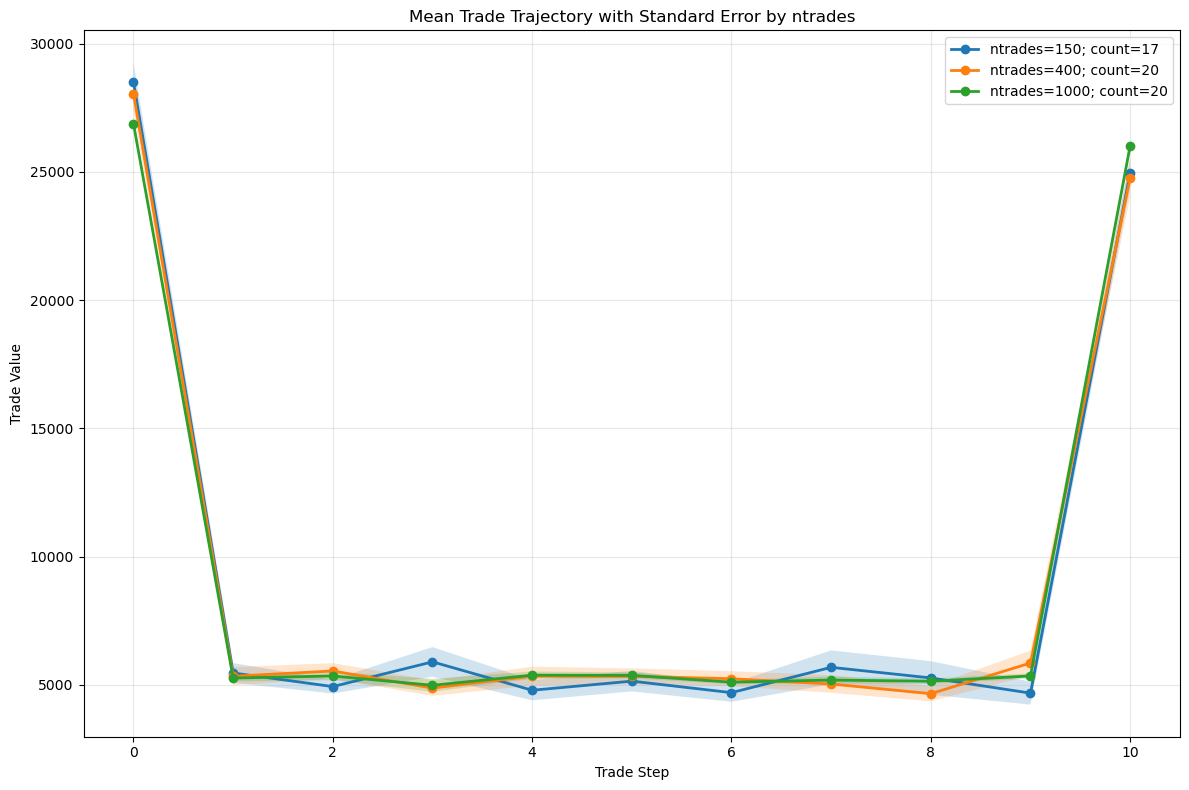

In [6]:
# Group by ntrades and calculate mean and standard error for each trade column
trade_cols = [f'trade_{j}' for j in range(11)]
df_success = df[df.status == 2]
ntrades_groups = df_success.groupby('ntrades')

plt.figure(figsize=(12, 8))

# Get unique ntrades values and sort them
ntrades_values = sorted(df_success['ntrades'].unique())[-3:]

for ntrades in ntrades_values:
    group_data = ntrades_groups.get_group(ntrades)
    
    # Calculate mean and standard error for each trade column
    means = []
    std_errors = []
    
    for col in trade_cols:
        mean_val = group_data[col].mean()
        std_val = group_data[col].std()
        n_samples = len(group_data)
        std_error = std_val / np.sqrt(n_samples)
        
        means.append(mean_val)
        std_errors.append(std_error)
    
    means = np.array(means)
    std_errors = np.array(std_errors)
    x = np.arange(11)  # Trade steps 0 to 10
    
    # Plot mean trajectory
    plt.plot(x, means, marker='o', label=f'ntrades={ntrades}; count={len(group_data)}', linewidth=2)
    
    # Add standard error bands
    plt.fill_between(x, means - std_errors, means + std_errors, alpha=0.2)

plt.xlabel('Trade Step')
plt.ylabel('Trade Value')
plt.title('Mean Trade Trajectory with Standard Error by ntrades')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

for chance_threshold in [0.03, 0.05, 0.07, 0.1]:
    print(f"Chance threshold: {chance_threshold}")
    if chance_threshold == 0.05:
        base_dir = '/nfs/home/dannis/AC-model/TIM_opt_results_20250830'
    else:
        base_dir = '/nfs/home/dannis/AC-model/TIM_opt_results_20250909_thresh' + str(int(chance_threshold*100))
    df_subset = df[df['ntrades'] == chance_threshold]
    print(df_subset.groupby('status').size())
    print(df_subset[['obj_val']].describe())
    print("\n")